**PROJECT TEAM ID**: PTID-CDS-DEC-25-3516    

**PROJECT CODE** : PRCP-1003-Customer Transaction Prediction

**PROJECT NAME** : Customer Transaction Prediction

# Customer Transaction Prediction
### PRCP-1003 Capstone Project

**Domain:** Banking  
**Objective:** Predict whether a customer will make a transaction in the future.

##  1. Business Case

Banks need to identify customers who are likely to make transactions in the future. This project aims to build a machine learning classification model that predicts customer transaction behavior (Yes/No) using historical data.

## 2. Domain Analysis
**Domain: Banking**

**Problem Type: Binary Classification**

- Dataset is anonymized
- 200 numerical features
- ID_code: Unique customer identifier
- Target variable:
  - 0 → No transaction
  - 1 → Transaction

Detailed EDA is limited due to anonymized features.

## Task 1: Data Analysis Report

### 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

### 2. Load Dataset

In [ ]:
df = pd.read_csv("train(1).csv")

### 3. Basic Data Checks

In [ ]:
df.shape   #Shows number of rows and columns in dataset

(3474, 202)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3474 entries, 0 to 3473
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 5.4+ MB


In [ ]:
df.isnull().sum()

,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
...,...
var_195,1
var_196,1
var_197,1
var_198,1


#### handle missing values

In [ ]:
# Get columns with missing values
missing_cols = df.columns[df.isnull().sum() > 0]

print("Columns with missing values:", missing_cols)
print(df[missing_cols].isnull().sum())

Columns with missing values: Index(['var_157', 'var_158', 'var_159', 'var_160', 'var_161', 'var_162',
       'var_163', 'var_164', 'var_165', 'var_166', 'var_167', 'var_168',
       'var_169', 'var_170', 'var_171', 'var_172', 'var_173', 'var_174',
       'var_175', 'var_176', 'var_177', 'var_178', 'var_179', 'var_180',
       'var_181', 'var_182', 'var_183', 'var_184', 'var_185', 'var_186',
       'var_187', 'var_188', 'var_189', 'var_190', 'var_191', 'var_192',
       'var_193', 'var_194', 'var_195', 'var_196', 'var_197', 'var_198',
       'var_199'],
      dtype='object')
var_157    1
var_158    1
var_159    1
var_160    1
var_161    1
var_162    1
var_163    1
var_164    1
var_165    1
var_166    1
var_167    1
var_168    1
var_169    1
var_170    1
var_171    1
var_172    1
var_173    1
var_174    1
var_175    1
var_176    1
var_177    1
var_178    1
var_179    1
var_180    1
var_181    1
var_182    1
var_183    1
var_184    1
var_185    1
var_186    1
var_187    1
var_188    1
var

In [ ]:
from sklearn.impute import SimpleImputer

if len(missing_cols) > 0:
    imputer = SimpleImputer(strategy='median')
    df[missing_cols] = imputer.fit_transform(df[missing_cols])
else:
    print("No missing values to impute.")

In [ ]:
df.isnull().sum()

,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
...,...
var_195,0
var_196,0
var_197,0
var_198,0


In [ ]:
df.duplicated().sum()   #No duplicate rows found

np.int64(0)

#### Target Variable Distribution (Class Imbalance)

In [ ]:
df['target'].value_counts()

,count
target,
0,3122
1,352


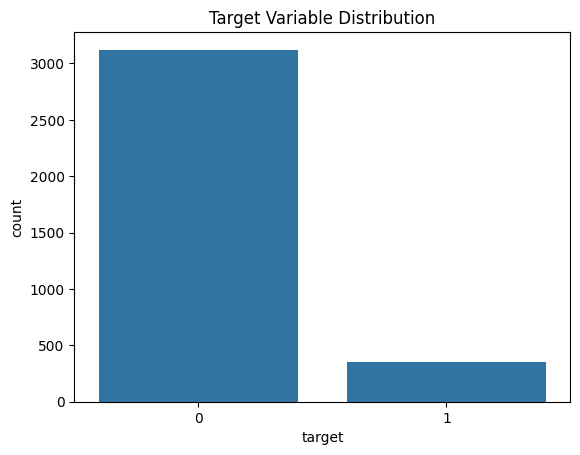

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Target Variable Distribution")
plt.show()

### insight

Majority class = 0

Minority class = 1

**Dataset is imbalanced**

#### Statistical Summary

In [ ]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,...,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000,3474.000000
mean,0.101324,10.736657,-1.634805,10.658921,6.827374,11.067125,-5.072638,5.390552,16.596089,0.320949,...,3.256645,7.385228,1.948814,3.287932,18.005794,-0.138495,2.220381,8.910921,15.893891,-3.299398
std,0.301801,3.031119,4.132123,2.644206,2.065974,1.625100,7.983062,0.872476,3.399860,3.345504,...,4.611799,3.010935,1.496867,3.983403,3.202399,1.416870,5.439698,0.932342,2.991594,10.497971
min,0.000000,1.335000,-13.422700,3.678500,1.154100,6.361100,-29.013300,2.673300,8.017000,-9.476600,...,-11.593900,-1.215800,-2.927700,-8.922900,10.767500,-4.488300,-12.325500,6.343300,7.233700,-36.302500
25%,0.000000,8.522675,-4.749125,8.621775,5.225300,9.838450,-11.339375,4.749500,14.053850,-2.334825,...,-0.082475,5.116525,0.914550,0.543450,15.565200,-1.153775,-2.086000,8.254850,13.861425,-11.375400
50%,0.000000,10.592400,-1.640850,10.557600,6.846150,11.082100,-4.875650,5.359950,16.588500,0.389150,...,3.274500,7.266500,1.956800,3.376100,17.977100,-0.179700,2.437700,8.897900,15.949100,-2.991400
75%,0.000000,12.765675,1.279700,12.455475,8.388850,12.268350,1.039325,6.001150,19.042100,2.976050,...,6.414275,9.461400,2.983875,6.156350,20.530200,0.807375,6.306250,9.597975,18.102075,4.900950
max,1.000000,19.289300,8.416000,18.347700,12.674000,15.110800,17.251600,7.875500,26.284800,8.482900,...,16.211600,15.686300,7.139000,16.103300,26.628500,3.555400,14.843600,11.843900,25.442200,25.094400


## insights

Features have different scales

Presence of extreme values

Scaling is required

## Summary of Task 1

* Dataset is clean and well-structured

* No missing or duplicate data

* Target variable is imbalanced

* All features are numerical

* Suitable for binary classification

##  Conclusion of Task 1

* Task 1 successfully provided a basic understanding of the dataset. Since feature names are anonymized, detailed EDA was skipped as instructed. The data is ready for preprocessing and predictive model building in Task 2.

# TASK 2: Predictive Model Building

### Data Preparation

In [ ]:
X = df.drop(['ID_code', 'target'], axis=1)
y = df['target']


#### Feature and Target Separation
ID_code is removed as it does not contribute to prediction.

target is separated as output variable.

### Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

* Stratified splitting is used to maintain class distribution due to class imbalance.
* use SMOTE foe handle imbalance dataset

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())


Before SMOTE: target
0    2497
1     282
Name: count, dtype: int64
After SMOTE: target
0    2497
1    2497
Name: count, dtype: int64


### Feature Scaling

* Standardization is applied to ensure all features are on the same scale.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Model Building

In [ ]:
def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print('-'*50)

## Models BEFORE Hyperparameter Tuning

In [ ]:
print("### MODELS BEFORE HYPERPARAMETER TUNING ###")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train_res)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model('Logistic Regression (Before Tuning)', y_test, y_pred_lr)

# Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train_scaled, y_train_res)
y_pred_dt = dt.predict(X_test_scaled)
evaluate_model('Decision Tree (Before Tuning)', y_test, y_pred_dt)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train_res)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_model('Random Forest (Before Tuning)', y_test, y_pred_rf)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train_res)
y_pred_knn = knn.predict(X_test_scaled)
evaluate_model('KNN (Before Tuning)', y_test, y_pred_knn)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train_res)
y_pred_nb = nb.predict(X_test_scaled)
evaluate_model('Naive Bayes (Before Tuning)', y_test, y_pred_nb)


### MODELS BEFORE HYPERPARAMETER TUNING ###
--- Logistic Regression (Before Tuning) ---
Accuracy: 0.7956834532374101
ROC-AUC: 0.7088
Confusion Matrix:
 [[511 114]
 [ 28  42]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88       625
           1       0.27      0.60      0.37        70

    accuracy                           0.80       695
   macro avg       0.61      0.71      0.62       695
weighted avg       0.88      0.80      0.83       695

--------------------------------------------------
--- Decision Tree (Before Tuning) ---
Accuracy: 0.7266187050359713
ROC-AUC: 0.5372
Confusion Matrix:
 [[484 141]
 [ 49  21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.77      0.84       625
           1       0.13      0.30      0.18        70

    accuracy                           0.73       695
   macro avg       0.52      0.54      0.51       695
we

##  Hyperparameter Tuning

###  1. Logistic Regression

In [ ]:
# 11.1 Logistic Regression
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train_res)
best_lr = lr_grid.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_scaled)
evaluate_model('Logistic Regression (After Tuning)', y_test, y_pred_lr_tuned)

--- Logistic Regression (After Tuning) ---
Accuracy: 0.8057553956834532
ROC-AUC: 0.7270857142857143
Confusion Matrix:
 [[516 109]
 [ 26  44]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.88       625
           1       0.29      0.63      0.39        70

    accuracy                           0.81       695
   macro avg       0.62      0.73      0.64       695
weighted avg       0.89      0.81      0.83       695

--------------------------------------------------


###  2. Decision Tree

In [ ]:
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': ['balanced']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='roc_auc', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train_res)
best_dt = dt_grid.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test_scaled)
evaluate_model('Decision Tree (After Tuning)', y_test, y_pred_dt_tuned)

--- Decision Tree (After Tuning) ---
Accuracy: 0.7251798561151079
ROC-AUC: 0.5427428571428572
Confusion Matrix:
 [[482 143]
 [ 48  22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.77      0.83       625
           1       0.13      0.31      0.19        70

    accuracy                           0.73       695
   macro avg       0.52      0.54      0.51       695
weighted avg       0.83      0.73      0.77       695

--------------------------------------------------


### 3.Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=10,          # 🔥 only 10 models
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train_scaled, y_train_res)

best_rf = rf_random.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)

evaluate_model('Random Forest (After Tuning)', y_test, y_pred_rf_tuned)


--- Random Forest (After Tuning) ---
Accuracy: 0.9007194244604316
ROC-AUC: 0.5071428571428571
Confusion Matrix:
 [[625   0]
 [ 69   1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95       625
           1       1.00      0.01      0.03        70

    accuracy                           0.90       695
   macro avg       0.95      0.51      0.49       695
weighted avg       0.91      0.90      0.86       695

--------------------------------------------------


### 4.KNN

In [31]:
# 11.4 KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='roc_auc', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train_res)
best_knn = knn_grid.best_estimator_
y_pred_knn_tuned = best_knn.predict(X_test_scaled)
evaluate_model('KNN (After Tuning)', y_test, y_pred_knn_tuned)

--- KNN (After Tuning) ---
Accuracy: 0.10071942446043165
ROC-AUC: 0.5
Confusion Matrix:
 [[  0 625]
 [  0  70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       625
           1       0.10      1.00      0.18        70

    accuracy                           0.10       695
   macro avg       0.05      0.50      0.09       695
weighted avg       0.01      0.10      0.02       695

--------------------------------------------------


###  Note: Naive Bayes has no hyperparameters for tuning.

###   Model Comparison Report

In [32]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression (Before)', 'Logistic Regression (After)',
              'Decision Tree (Before)', 'Decision Tree (After)',
              'Random Forest (Before)', 'Random Forest (After)',
              'KNN (Before)', 'KNN (After)',
              'Naive Bayes (Before)'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_lr_tuned),
                 accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_dt_tuned),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_rf_tuned),
                 accuracy_score(y_test, y_pred_knn),
                 accuracy_score(y_test, y_pred_knn_tuned),
                 accuracy_score(y_test, y_pred_nb)],
    'ROC-AUC': [roc_auc_score(y_test, y_pred_lr),
                roc_auc_score(y_test, y_pred_lr_tuned),
                roc_auc_score(y_test, y_pred_dt),
                roc_auc_score(y_test, y_pred_dt_tuned),
                roc_auc_score(y_test, y_pred_rf),
                roc_auc_score(y_test, y_pred_rf_tuned),
                roc_auc_score(y_test, y_pred_knn),
                roc_auc_score(y_test, y_pred_knn_tuned),
                roc_auc_score(y_test, y_pred_nb)]
})

print(comparison)


                          Model  Accuracy   ROC-AUC
0  Logistic Regression (Before)  0.795683  0.708800
1   Logistic Regression (After)  0.805755  0.727086
2        Decision Tree (Before)  0.726619  0.537200
3         Decision Tree (After)  0.725180  0.542743
4        Random Forest (Before)  0.899281  0.506343
5         Random Forest (After)  0.900719  0.507143
6                  KNN (Before)  0.100719  0.500000
7                   KNN (After)  0.100719  0.500000
8          Naive Bayes (Before)  0.876259  0.518914



* **Multiple machine learning models were evaluated to predict customer transaction behavior in the banking domain.Due to class imbalance, SMOTE was applied, and model performance was primarily assessed using ROC-AUC along with accuracy.**



* **Among all models, Logistic Regression after hyperparameter tuning delivered the best performance, achieving the highest ROC-AUC score (0.7271) with stable accuracy (0.8058). This indicates strong class discrimination and reliable predictions.**



* **Decision Tree models showed moderate performance with low ROC-AUC, indicating instability. Random Forest and KNN achieved high accuracy but ROC-AUC values close to 0.5, revealing majority-class bias and poor learning. Naive Bayes performed reasonably but was still inferior to Logistic Regression.**

# Logistic Regression (After Hyperparameter Tuning)

**Logistic Regression (after hyperparameter tuning) is the best model for dataset.**

* It has the highest ROC-AUC among all models you tested.

* It gives stable, meaningful predictions (not just majority-class guessing).

* It suits banking data and remains interpretable.

#### Other models:

**Random Forest & KNN**

* High accuracy but ROC-AUC = 0.5

* Means no real learning

**Decision Tree**

* Unstable, accuracy dropped after tuning

**Naive Bayes**

* Good, but still slightly worse ROC-AUC than Logistic Regression

## save model & create GUI

In [37]:
import numpy as np

# Generate 200 random numbers between 0 and 1
test_input = ",".join(map(str, np.round(np.random.rand(200), 2)))
print(test_input)


0.04,0.4,0.13,0.43,0.74,0.12,0.94,0.46,0.12,0.94,0.96,0.8,0.34,0.64,0.04,0.24,0.16,0.21,0.63,0.71,0.99,0.65,0.68,0.87,0.44,0.44,0.09,0.49,0.85,0.82,0.13,0.96,0.8,0.63,0.69,0.12,0.76,0.6,0.58,0.16,0.95,0.99,0.44,0.84,0.29,0.33,0.78,0.01,0.87,0.41,0.27,0.76,0.78,0.68,0.36,0.02,0.88,0.21,0.06,0.25,0.71,0.48,0.12,0.81,0.87,0.81,0.2,0.56,0.04,0.12,0.59,0.5,0.48,0.52,0.42,0.82,0.12,0.0,0.33,0.96,0.58,0.81,0.61,0.22,0.3,0.99,0.78,0.27,0.06,0.12,0.45,0.92,0.08,0.96,0.33,0.2,0.45,0.37,0.64,0.41,0.2,0.89,0.37,0.9,0.52,0.51,0.09,0.75,0.67,0.31,0.73,0.51,0.16,0.78,0.25,0.7,0.36,0.5,0.67,0.24,0.97,0.23,0.52,0.22,0.54,0.61,0.52,0.32,0.82,0.15,0.0,0.21,0.11,0.79,0.47,0.63,0.45,0.21,0.49,0.29,0.4,0.16,0.04,0.45,0.92,0.6,0.43,0.01,0.58,0.55,0.11,0.83,0.27,0.82,0.46,0.61,0.36,0.43,0.6,0.56,0.67,0.17,0.84,0.28,0.44,0.53,0.89,0.63,0.4,0.47,0.59,0.07,0.66,0.88,0.58,0.35,0.22,0.52,0.67,0.72,0.19,0.77,0.61,0.95,0.26,0.35,0.62,0.03,0.9,0.44,0.91,0.02,0.23,0.45,0.26,0.93,0.39,0.73,0.77,0.19


In [35]:
import numpy as np
import joblib

def predict_transaction():
    model = joblib.load("logistic_model_smote_tuned.pkl")
    scaler = joblib.load("scaler_smote.pkl")

    user_input = input("Enter 200 feature values (comma separated):\n")

    try:
        values = [float(x.strip()) for x in user_input.split(",")]

        if len(values) != 200:
            print("❌ Error: Exactly 200 values required!")
            return

        X = np.array(values).reshape(1, -1)
        X_scaled = scaler.transform(X)

        pred = model.predict(X_scaled)[0]
        prob = model.predict_proba(X_scaled)[0][1]

        if pred == 1:
            print(f"✅ Transaction YES (Probability: {prob:.2f})")
        else:
            print(f"❌ Transaction NO (Probability: {prob:.2f})")

    except ValueError:
        print("❌ Invalid input. Use comma-separated numeric values only.")


In [38]:
predict_transaction()


Enter 200 feature values (comma separated):
0.04,0.4,0.13,0.43,0.74,0.12,0.94,0.46,0.12,0.94,0.96,0.8,0.34,0.64,0.04,0.24,0.16,0.21,0.63,0.71,0.99,0.65,0.68,0.87,0.44,0.44,0.09,0.49,0.85,0.82,0.13,0.96,0.8,0.63,0.69,0.12,0.76,0.6,0.58,0.16,0.95,0.99,0.44,0.84,0.29,0.33,0.78,0.01,0.87,0.41,0.27,0.76,0.78,0.68,0.36,0.02,0.88,0.21,0.06,0.25,0.71,0.48,0.12,0.81,0.87,0.81,0.2,0.56,0.04,0.12,0.59,0.5,0.48,0.52,0.42,0.82,0.12,0.0,0.33,0.96,0.58,0.81,0.61,0.22,0.3,0.99,0.78,0.27,0.06,0.12,0.45,0.92,0.08,0.96,0.33,0.2,0.45,0.37,0.64,0.41,0.2,0.89,0.37,0.9,0.52,0.51,0.09,0.75,0.67,0.31,0.73,0.51,0.16,0.78,0.25,0.7,0.36,0.5,0.67,0.24,0.97,0.23,0.52,0.22,0.54,0.61,0.52,0.32,0.82,0.15,0.0,0.21,0.11,0.79,0.47,0.63,0.45,0.21,0.49,0.29,0.4,0.16,0.04,0.45,0.92,0.6,0.43,0.01,0.58,0.55,0.11,0.83,0.27,0.82,0.46,0.61,0.36,0.43,0.6,0.56,0.67,0.17,0.84,0.28,0.44,0.53,0.89,0.63,0.4,0.47,0.59,0.07,0.66,0.88,0.58,0.35,0.22,0.52,0.67,0.72,0.19,0.77,0.61,0.95,0.26,0.35,0.62,0.03,0.9,0.44,0.91,0.02,0.23,0.45,0.26,

# Report on Challenges faced



Challenges Faced and Solutions – Customer Transaction Prediction

**Missing Values:**

* Challenge: Some features had missing values.

* Solution: Used median imputation with SimpleImputer.

**Reason: Median is robust to outliers and preserves feature distribution.**

**Class Imbalance:**

* Challenge: Target variable was imbalanced.

* Solution: Applied SMOTE to oversample the minority class.

**Reason: Balances classes, improving model performance (ROC-AUC, precision, recall).**

**Feature Scaling:**

* Challenge: Models like Logistic Regression, KNN, and SVM are sensitive to feature scales.

* Solution: Applied StandardScaler.

**Reason: Ensures uniform feature contribution and faster convergence.**

**Hyperparameter Tuning:**

* Challenge: Default parameters gave suboptimal performance.

* Solution: Used GridSearchCV / RandomizedSearchCV for tuning.

**Reason: Optimizes model performance and prevents under/overfitting.**

**High-Dimensional Input (200 features):**

* Challenge: Could cause slow training or feature dominance.

* Solution: Scaling and tree-based models.

**Reason: Handles many features efficiently.**

**Overfitting Risk:**

* Challenge: Tree-based models may overfit on oversampled data.

* Solution: Limited tree depth and used cross-validation.

**Reason: Improves generalization on unseen data.**

**Conclusion:**
* By addressing missing values, class imbalance, scaling, hyperparameter tuning, and validation, the project ensures accurate, robust, and reliable transaction predictions.
